In [2]:
import glob
import numpy as np
from seticore import viewer
from pprint import pprint

STAMPS_GLOB = "../stamp_data/*.stamps"
paths = glob.glob(STAMPS_GLOB, recursive=True)
print(f"Found {len(paths)} .stamps files")

stamps = []
for path in paths:
    stamps.extend(viewer.read_stamps(path, find_recipe=True))

print(f"Loaded {len(stamps)} total stamps")

def extract_spectrum(stamp):
    arr = stamp.real_array()
    power = np.abs(arr)**2
    return power.sum(axis=(2, 3, 4))

arrays = []
for i, s in enumerate(stamps):
    spectrum = extract_spectrum(s)
    arrays.append(spectrum)



kj/filesystem-disk-unix.c++:1734: warning: PWD environment variable doesn't match current directory; pwd = /mnt_home/jaym


Found 1 .stamps files
Loaded 60 total stamps


Plotting 1 spectra...


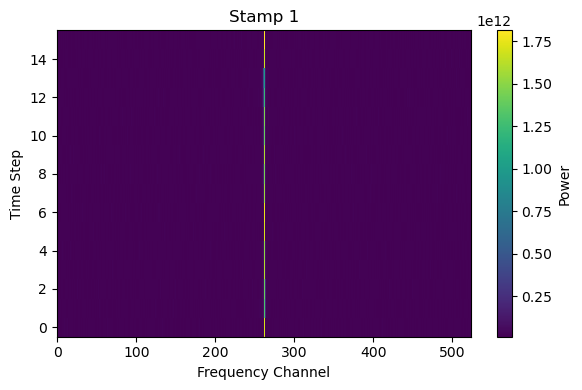

In [3]:
import matplotlib.pyplot as plt

# Configure plots
n = 1
print(f"Plotting {n} spectra...")

# Plot each spectrum as a waterfall plot
for i, spec in enumerate(arrays):
    if i == 0:
        plt.figure(figsize=(6, 4))
        plt.imshow(
            spec,
            aspect='auto',
            origin='lower',
            cmap='viridis',
            interpolation='none'
        )
        plt.title(f"Stamp {i + 1}")
        plt.xlabel("Frequency Channel")
        plt.ylabel("Time Step")
        plt.colorbar(label='Power')
        plt.tight_layout()
        plt.show()


In [ ]:
import numpy as np

widths = [a.shape[1] for a in arrays]
target_W = 640

def augment_stamp(a):
    # Random horizontal flip (frequency axis)
    if np.random.rand() < 0.5:
        a = np.flip(a, axis=1)
    # Random vertical flip (time axis)
    if np.random.rand() < 0.5:
        a = np.flip(a, axis=0)
    # Random frequency-axis translation
    max_shift = int(a.shape[1] * 0.1)
    shift = np.random.randint(-max_shift, max_shift + 1)
    if shift != 0:
        a = np.roll(a, shift, axis=1)
    return a

def pad_or_crop_chisq(a, W=target_W):   # this will pad with chi squared noise based on the signal mean
    t, v = a.shape
    dtype = a.dtype
    if v < W:
        pad_total = W - v
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left

        signal_mean = np.mean(a)
        noise_left = np.random.chisquare(df=2, size=(t, pad_left)).astype(dtype) * signal_mean / 2
        noise_right = np.random.chisquare(df=2, size=(t, pad_right)).astype(dtype) * signal_mean / 2

        return np.concatenate([noise_left, a, noise_right], axis=1)
    else:
        start = (v - W) // 2
        return a[:, start:start+W]
    
def pad_or_crop_mirror(a, W=target_W):  # this will take the edges and mirror to pad
    t, v = a.shape
    if v < W:
        pad_total = W - v
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        left_pad = np.flip(a[:, :pad_left], axis=1)
        right_pad = np.flip(a[:, -pad_right:], axis=1)
        return np.concatenate([left_pad, a, right_pad], axis=1)
    else:
        start = (v - W) // 2
        return a[:, start:start + W]


# Generate augmented copies + 1 original → then pad each
arrays_augmented = []

for a in arrays:
    # Original (no augmentation)
    padded_orig = pad_or_crop_chisq(a)
    arrays_augmented.append(padded_orig)

    # three augmentations
    for _ in range(2):
        augmented = augment_stamp(a.copy())
        padded = pad_or_crop_chisq(augmented)
        arrays_augmented.append(padded)
        
X = np.stack(arrays_augmented, axis=0)  # shape → (10 × n_hits, 16, target_W)



(16, 524)
(16, 524)
(16, 524)
(16, 525)
(16, 524)
(16, 525)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 525)
(16, 570)
(16, 598)
(16, 606)
(16, 691)
(16, 677)
(16, 728)
(16, 722)
(16, 648)
(16, 524)
(16, 710)
(16, 705)
(16, 721)
(16, 696)
(16, 713)
(16, 639)
(16, 581)
(16, 696)
(16, 641)
(16, 542)
(16, 619)
(16, 599)
(16, 712)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 524)
(16, 525)
(16, 524)
(16, 524)
(16, 524)


In [5]:
# Normalize each stamp independently to [0, 1]
X_norm = np.empty_like(X)
for i in range(len(X)):
    stamp = X[i]
    vmin, vmax = stamp.min(), stamp.max()
    if vmax > vmin:
        X_norm[i] = (stamp - vmin) / (vmax - vmin)
    else:
        X_norm[i] = stamp  # all-zero or constant stamp → leave as is


# 2) Add channel axis for Conv2D
X_input    = X_norm[..., np.newaxis]       # → (n_hits, 16, target_W, 1)
X_input.shape


(180, 16, 640, 1)

/home/jaym/jay-env/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 16, 640, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 640, 32)    │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 640, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 640, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 320, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 320, 64)     │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 320, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 320, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 160, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 160, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 160, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 160, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 80, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │       655,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20480)          │       675,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2, 80, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 4, 160, 128)    │        49,280 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 160, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 4, 160, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 8, 320, 64)     │        24,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 320, 64)     │           25

 Total params: 1,444,449 (5.51 MB)

 Trainable params: 1,443,553 (5.51 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 497ms/step - loss: 0.1648 - val_loss: 0.1468
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 355ms/step - loss: 0.0824 - val_loss: 0.1414
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 377ms/step - loss: 0.0463 - val_loss: 0.1343
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 375ms/step - loss: 0.0296 - val_loss: 0.1260
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - loss: 0.0221 - val_loss: 0.1176
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 358ms/step - loss: 0.0200 - val_loss: 0.1096
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 352ms/step - loss: 0.0190 - val_loss: 0.1028
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step - loss: 0.0159 - val_loss: 0.0968
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 350ms/step - loss: 0.0167 - val_loss: 0.0918
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - loss: 0.0158 - val_loss: 0.0875
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 368ms/step - loss: 0.0170 - val_loss: 0.0838
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step - loss: 0.0

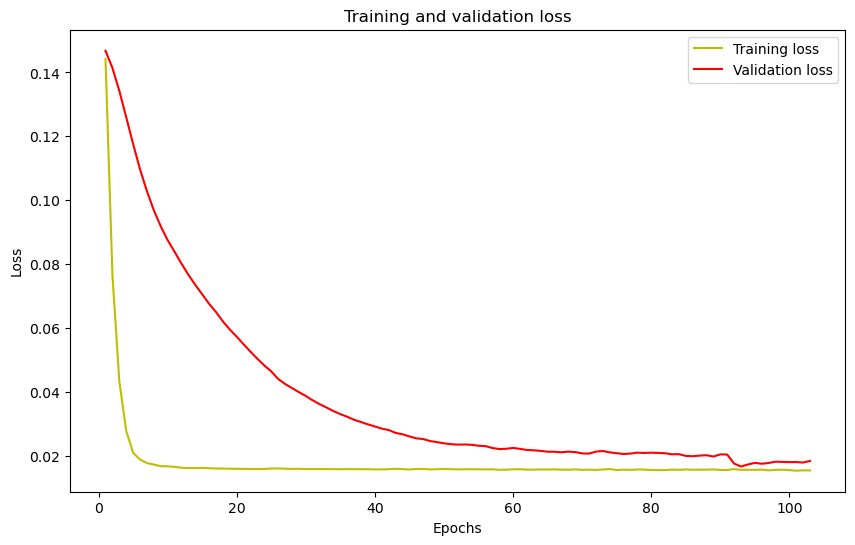

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    InputLayer,
    GaussianNoise,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Reshape,
    Conv2DTranspose,
    BatchNormalization,
    Activation
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Split data
X_train, X_val = train_test_split(X_input, test_size=0.2, random_state=42)

import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10, 6))

latent_dim = 32

model = Sequential([
    InputLayer(input_shape=(16, target_W, 1)),
    GaussianNoise(0.05),

    # ─── Encoder ─────────────────────────────────────
    Conv2D(32, (3, 1), padding='same'), BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2), padding='same'),  # → (8, W/2, 32)

    Conv2D(64, (3, 1), padding='same'), BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2), padding='same'),  # → (4, W/4, 64)

    Conv2D(128, (3, 1), padding='same'), BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2), padding='same'),  # → (2, W/8, 128)

    Flatten(),
    Dense(latent_dim, name="latent_vector"),

    # ─── Decoder ─────────────────────────────────────
    Dense(2 * (target_W // 8) * 128),  # reshape back to conv shape
    Reshape((2, target_W // 8, 128)),

    Conv2DTranspose(128, (3, 1), strides=(2, 2), padding='same'), BatchNormalization(), Activation('relu'),  # → (4, W/4, 128)
    Conv2DTranspose(64,  (3, 1), strides=(2, 2), padding='same'), BatchNormalization(), Activation('relu'),  # → (8, W/2, 64)
    Conv2DTranspose(32,  (3, 1), strides=(2, 2), padding='same'), BatchNormalization(), Activation('relu'),  # → (16, W, 32)

    Conv2D(1, (3, 3), activation='sigmoid', padding='same')  # final output shape → (16, W, 1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Add noise for denoising training
X_noisy = X_train + np.random.normal(0, 0.02, X_train.shape)
X_noisy = np.clip(X_noisy, 0, 1)

# ─── Train the model ────────────────────────────────
history = model.fit(
    X_noisy, X_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=True,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

# ─── Plot loss curves ───────────────────────────────
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


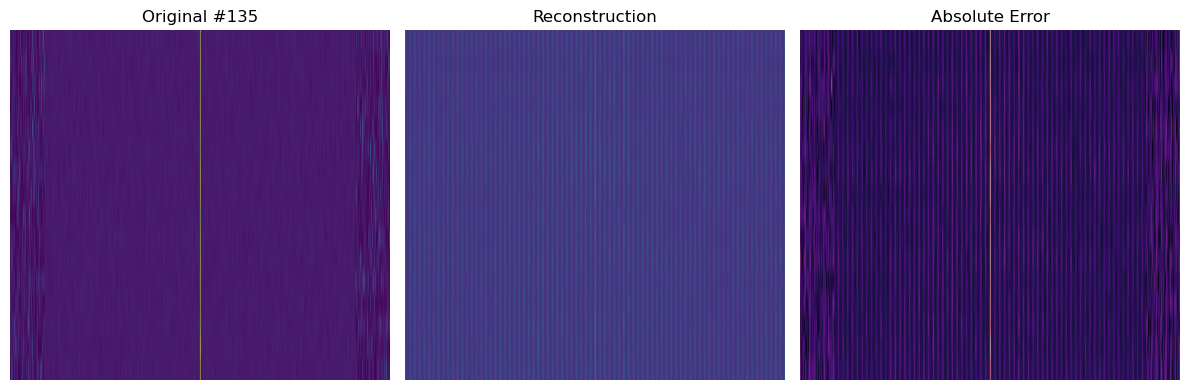

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


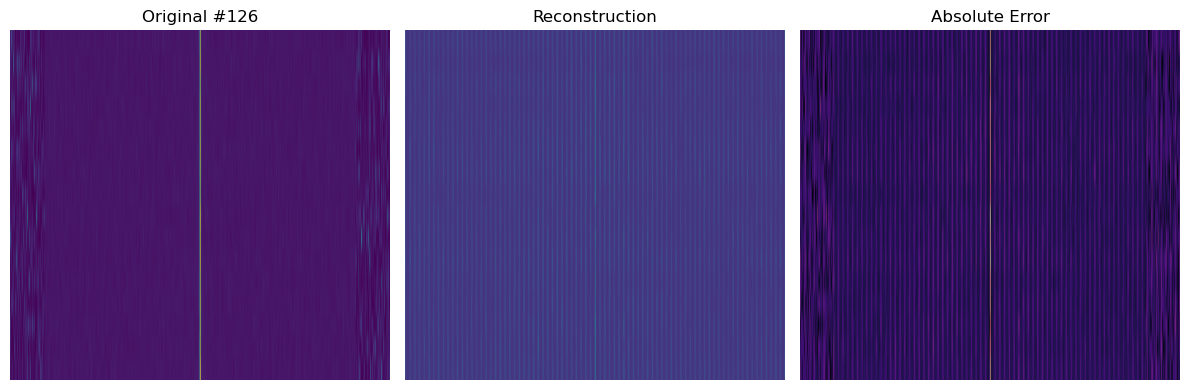

In [51]:
max_images = 2  # Number of random examples to show
total_images = len(X_input)

# Sample non-repeating random indices
random_indices = np.random.choice(total_images, size=min(max_images, total_images), replace=False)

for i, idx in enumerate(random_indices):
    orig = X_input[idx, ..., 0]
    recon = model.predict(X_input[idx:idx+1])[0, ..., 0]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
    vmin, vmax = orig.min(), orig.max()

    ax1.imshow(orig, aspect='auto', vmin=vmin, vmax=vmax)
    ax1.set_title(f'Original #{idx}')
    ax1.axis('off')

    ax2.imshow(recon, aspect='auto', vmin=vmin, vmax=vmax)
    ax2.set_title('Reconstruction')
    ax2.axis('off')

    ax3.imshow(np.abs(orig - recon), aspect='auto', cmap='magma')
    ax3.set_title('Absolute Error')
    ax3.axis('off')

    plt.tight_layout()
    plt.show()

In [66]:
def plot_stamps(input_stamps, title, max_stamps=20, stamps_per_row=5, cmap='viridis'):
    n = min(len(input_stamps), max_stamps)
    n_cols = stamps_per_row
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = np.ravel(axes) if isinstance(axes, np.ndarray) else [axes]  # <== FIX

    for i in range(n):
        stamp = input_stamps[i, ..., 0]
        vmin, vmax = stamp.min(), stamp.max()
        axes[i].imshow(stamp, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        axes[i].axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [53]:
# Manually slice up to and including the latent_vector layer
latent_layer_index = [i for i, l in enumerate(model.layers) if l.name == "latent_vector"][0]
encoder = Sequential(model.layers[:latent_layer_index + 1])

# Predict latent vectors
latent_vectors = encoder.predict(X_input, batch_size=128)
print(latent_vectors.shape)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
(180, 32)


Latent vector shape: (180, 32)


/home/jaym/jay-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


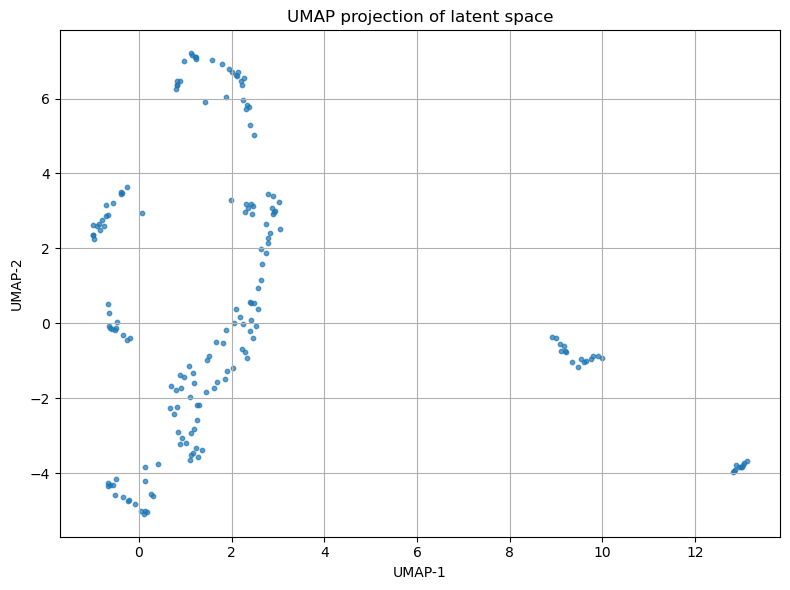

In [54]:
from umap import UMAP

# Create UMAP projection of latent space
print(f"Latent vector shape: {latent_vectors.shape}")  # → (n_samples, latent_dim)

# Reduce to 2D with UMAP
reducer = UMAP(n_components=2, random_state=42)
latent_2d = reducer.fit_transform(latent_vectors)

# Plot with matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], s=10, alpha=0.7)
plt.title("UMAP projection of latent space")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.tight_layout()
plt.show()


/home/jaym/jay-env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


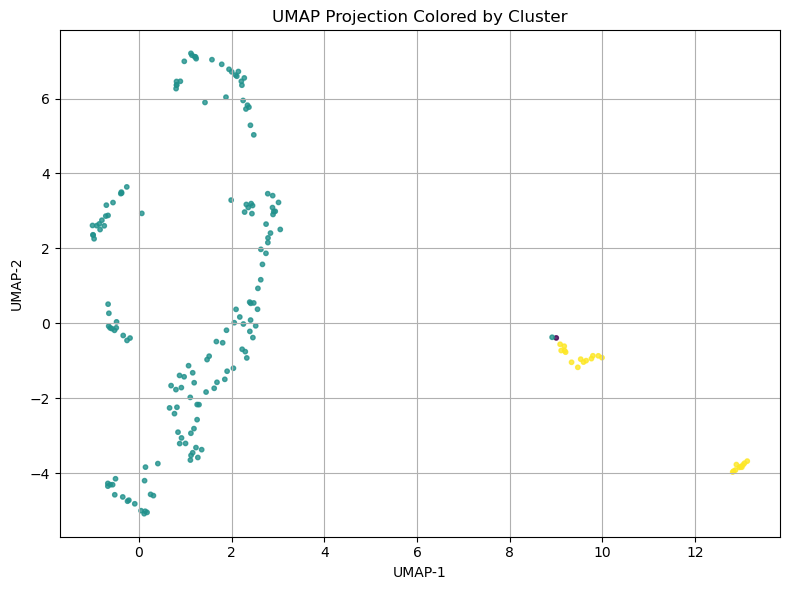

In [57]:
from sklearn.cluster import HDBSCAN
import matplotlib.pyplot as plt

graph = True

# Assume latent_vectors is (n_samples, latent_dim)
clusterer = HDBSCAN(min_cluster_size=10, n_jobs=-1)
clusterer.fit(latent_vectors)

labels = clusterer.labels_                           # shape: (n_samples,)
probabilities = getattr(clusterer, "probabilities_", None)

# Optional UMAP projection
if graph:
    reducer = UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(latent_vectors)   # shape: (n_samples, 2)

    # Color by cluster
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='viridis', s=10, alpha=0.8)
    plt.title("UMAP Projection Colored by Cluster")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [1]:
num_to_print = 1
unique_labels = np.unique(labels)
for i, label in enumerate(unique_labels):
    if i < num_to_print:
        cluster_stamps = X_input[labels == label]
        plot_stamps(cluster_stamps, title=f'Cluster {label}', max_stamps=50)


NameError: name 'np' is not defined